In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [4]:
import numpy as np
import pandas as pd

# 1. Generate 24-hour baseline profile for a 10MW solar portfolio in Berlin
hours = pd.date_range(start="2026-08-28 00:00", periods=24, freq="H")
base_capacity_factor = np.array(
    [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.2,
        0.15,
        0.30,
        0.50,
        0.70,
        0.85,
        0.90,  # Peak hours around noon
        0.85,
        0.70,
        0.50,
        0.30,
        0.15,
        0.05,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ]
)

# 2. Inject a sudden thunderstorm shock at hour 11 (11:00 AM)
actual_capacity_factor = base_capacity_factor.copy()
actual_capacity_factor[11] = 0.06  # Sharp drop during the storm hour

df_solar = pd.DataFrame(
    {
        "Timestamp": hours,
        "Scheduled_CF": base_capacity_factor,
        "Actual_CF": actual_capacity_factor,
    }
)

# Calculate the generation error / imbalance position (MW) for a 10MW plant
capacity_mw = 10.0
df_solar["Scheduled_MW"] = df_solar["Scheduled_CF"] * capacity_mw
df_solar["Actual_MW"] = df_solar["Actual_CF"] * capacity_mw
df_solar["Imbalance_MW"] = df_solar["Actual_MW"] - df_solar["Scheduled_MW"]

print(
    df_solar.loc[
        8:14, ["Timestamp", "Scheduled_MW", "Actual_MW", "Imbalance_MW"]
    ]
)

             Timestamp  Scheduled_MW  Actual_MW  Imbalance_MW
8  2026-08-28 08:00:00           5.0        5.0           0.0
9  2026-08-28 09:00:00           7.0        7.0           0.0
10 2026-08-28 10:00:00           8.5        8.5           0.0
11 2026-08-28 11:00:00           9.0        0.6          -8.4
12 2026-08-28 12:00:00           8.5        8.5           0.0
13 2026-08-28 13:00:00           7.0        7.0           0.0
14 2026-08-28 14:00:00           5.0        5.0           0.0


/tmp/ipykernel_3960/3223530776.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start="2026-08-28 00:00", periods=24, freq="H")


In [6]:
# 3. Simulate Nowcasting Warning & Intraday Mitigation
df_solar["Nowcast_Alert"] = False
df_solar.loc[11, "Nowcast_Alert"] = True  # Flagging the critical hour

# Financial variables for hour 11
id_vwap_price = 162.0  # EUR/MWh
rebap_spike_price = 3730.0  # EUR/MWh

imbalance_mw = abs(df_solar.loc[11, "Imbalance_MW"])  # 8.4 MW shortfall

cost_without_nowcasting = imbalance_mw * rebap_spike_price
cost_with_nowcasting = imbalance_mw * id_vwap_price
savings = cost_without_nowcasting - cost_with_nowcasting

print(f"--- Tail-Risk Mitigation Results for Hour 11 ---")
print(
    f"Cost WITHOUT Nowcasting (reBAP penalty): €{cost_without_nowcasting:,.2f}"
)
print(f"Cost WITH Nowcasting (Intraday VWAP cover): €{cost_with_nowcasting:,.2f}")
print(f"Total Net Savings for this single hour: €{savings:,.2f}")

--- Tail-Risk Mitigation Results for Hour 11 ---
Cost WITHOUT Nowcasting (reBAP penalty): €31,332.00
Cost WITH Nowcasting (Intraday VWAP cover): €1,360.80
Total Net Savings for this single hour: €29,971.20


In [8]:
import numpy as np
import pandas as pd
import pulp

# 1. Initialize PuLP Model
prob = pulp.LpProblem("BESS_TailRisk_Optimization", pulp.LpMinimize)
T = range(24)

# BESS Technical Parameters
max_power_mw = 10.0
max_energy_mwh = 20.0
initial_soc = 10.0
eta = 0.95  # Efficiency factor

# Decision Variables: separate charge and discharge for linear programming
p_charge = pulp.LpVariable.dicts(
    "P_Charge", T, lowBound=0, upBound=max_power_mw
)
p_discharge = pulp.LpVariable.dicts(
    "P_Discharge", T, lowBound=0, upBound=max_power_mw
)
p_bess = pulp.LpVariable.dicts(
    "P_BESS", T, lowBound=-max_power_mw, upBound=max_power_mw
)
soc = pulp.LpVariable.dicts("SoC", T, lowBound=0, upBound=max_energy_mwh)

# Net BESS power action = Discharge - Charge
for t in T:
    prob += p_bess[t] == p_discharge[t] - p_charge[t]

# 2. Objective Function: Minimize total imbalance and operating cost
total_cost = 0
for t in T:
    net_imbalance = (
        df_solar.loc[t, "Imbalance_MW"] + p_bess[t]
    )  # Net error after BESS

    if df_solar.loc[t, "Nowcast_Alert"]:
        cost_coeff = id_vwap_price  # Mitigated ID VWAP price (€162)
    else:
        cost_coeff = (
            rebap_spike_price if t == 11 else 50.0
        )  # reBAP spike or normal cost

    total_cost += cost_coeff * net_imbalance

prob += total_cost

# 3. Constraints
# Initial SoC constraint
prob += (
    soc[0]
    == initial_soc + (eta * p_charge[0]) - (p_discharge[0] / eta)
)

# Battery Dynamics over time
for t in range(1, 24):
    prob += (
        soc[t]
        == soc[t - 1] + (eta * p_charge[t]) - (p_discharge[t] / eta)
    )

# Solve optimization
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# Extract results
df_solar["BESS_Action_MW"] = [p_bess[t].varValue for t in T]
df_solar["Net_Imbalance_MW"] = (
    df_solar["Imbalance_MW"] + df_solar["BESS_Action_MW"]
)

print("--- Optimization Status ---")
print(f"Status: {pulp.LpStatus[prob.status]}")
print(
    "\n--- Dispatch Results around the Storm Peak (Hours 10 to 12) ---"
)
print(
    df_solar.loc[
        10:12,
        [
            "Timestamp",
            "Actual_MW",
            "Scheduled_MW",
            "Imbalance_MW",
            "BESS_Action_MW",
            "Net_Imbalance_MW",
        ],
    ]
)

--- Optimization Status ---
Status: Optimal

--- Dispatch Results around the Storm Peak (Hours 10 to 12) ---
             Timestamp  Actual_MW  Scheduled_MW  Imbalance_MW  BESS_Action_MW  \
10 2026-08-28 10:00:00        8.5           8.5           0.0          -0.975   
11 2026-08-28 11:00:00        0.6           9.0          -8.4         -10.000   
12 2026-08-28 12:00:00        8.5           8.5           0.0           0.000   

    Net_Imbalance_MW  
10            -0.975  
11           -18.400  
12             0.000  


In [9]:
pip install streamlit numpy pandas pulp plotly streamlit-lottie requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.9 MB/s eta 0:00:00


In [10]:
import numpy as np
import pandas as pd
import pulp
import plotly.graph_objects as go
import streamlit as st
from streamlit_lottie import st_lottie
import requests

# --- CONFIGURATION ---
st.set_page_config(layout="wide", page_title="BESS Tail-Risk Optimizer")

# --- HELPER FUNCTIONS ---
@st.cache_data
def load_lottie_animation(url):
    """Loads a Lottie animation from a URL."""
    try:
        r = requests.get(url)
        if r.status_code == 200:
            return r.json()
        return None
    except Exception as e:
        st.error(f"Error loading Lottie animation: {e}")
        return None

# --- DATA & MODEL SETUP (Run once) ---
@st.cache_resource
def run_optimization():
    """Runs the complete Nowcasting and BESS Optimization pipeline."""
    # 1. Generate Data
    hours = pd.date_range(start="2026-08-28 00:00", periods=24, freq="H")
    base_cf = np.array([
        0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.15, 0.30, 0.50, 0.70, 0.85, 0.90,
        0.85, 0.70, 0.50, 0.30, 0.15, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ])
    actual_cf = base_cf.copy()
    actual_cf[11] = 0.06  # Storm shock

    df = pd.DataFrame({
        "Timestamp": hours,
        "Scheduled_CF": base_cf,
        "Actual_CF": actual_cf,
    })
    cap_mw = 10.0
    df["Scheduled_MW"] = df["Scheduled_CF"] * cap_mw
    df["Actual_MW"] = df["Actual_CF"] * cap_mw
    df["Imbalance_MW"] = df["Actual_MW"] - df["Scheduled_MW"]

    df["Nowcast_Alert"] = False
    df.loc[11, "Nowcast_Alert"] = True
    id_vwap = 162.0
    rebap_spike = 3730.0

    # 2. Optimization
    prob = pulp.LpProblem("BESS_TailRisk_Optimization", pulp.LpMinimize)
    T = range(24)
    max_p = 10.0
    max_e = 20.0
    initial_soc = 10.0
    eta = 0.95

    p_charge = pulp.LpVariable.dicts("P_Charge", T, lowBound=0, upBound=max_p)
    p_discharge = pulp.LpVariable.dicts("P_Discharge", T, lowBound=0, upBound=max_p)
    p_bess = pulp.LpVariable.dicts("P_BESS", T, lowBound=-max_p, upBound=max_p)
    soc = pulp.LpVariable.dicts("SoC", T, lowBound=0, upBound=max_e)

    for t in T:
        prob += p_bess[t] == p_discharge[t] - p_charge[t]

    total_cost = 0
    for t in T:
        net_imb = df.loc[t, "Imbalance_MW"] + p_bess[t]
        cost_coeff = id_vwap if df.loc[t, "Nowcast_Alert"] else (rebap_spike if t == 11 else 50.0)
        total_cost += cost_coeff * net_imb

    prob += total_cost
    prob += soc[0] == initial_soc + (eta * p_charge[0]) - (p_discharge[0] / eta)
    for t in range(1, 24):
        prob += soc[t] == soc[t-1] + (eta * p_charge[t]) - (p_discharge[t] / eta)

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    df["BESS_Action_MW"] = [p_bess[t].varValue for t in T]
    df["Net_Imbalance_MW"] = df["Imbalance_MW"] + df["BESS_Action_MW"]
    df["BESS_SoC_MWh"] = [soc[t].varValue for t in T]

    # Financials
    cost_no_bess = abs(df.loc[11, "Imbalance_MW"]) * rebap_spike
    cost_with_bess = abs(df.loc[11, "Net_Imbalance_MW"]) * id_vwap # assuming ID price for net error
    savings = cost_no_bess - cost_with_bess

    return df, savings

# --- UI COMPONENTS ---
def header_section():
    """Displays the animated header section."""
    col1, col2 = st.columns([2, 1])

    # Lottie animation URL (replace with any suitable JSON URL)
    lottie_url = "https://assets4.lottiefiles.com/packages/lf20_hcy3z27y.json"
    lottie_animation = load_lottie_animation(lottie_url)

    with col1:
        st.title("⚡ BESS Tail-Risk Compression Dashboard")
        st.markdown("""
        This dashboard demonstrates how an integrated **Solar Nowcasting** and **BESS Optimization** pipeline
        (using PuLP and Streamlit) mitigates the financial impact of extreme weather tail-risk events,
        specifically the sudden solar output drop scenario in the Berlin/50Hertz region.
        """)

    with col2:
        if lottie_animation:
            st_lottie(lottie_animation, height=250, key="⚡")

def kpi_section(df, savings):
    """Displays the key performance indicators."""
    st.subheader("Key Mitigation Results (Hour 11 - Thunderstorm Peak)")

    col1, col2, col3 = st.columns(3)

    imb_mw = abs(df.loc[11, "Imbalance_MW"])
    cost_no_bess = imb_mw * 3730.0
    cost_with_bess = abs(df.loc[11, "Net_Imbalance_MW"]) * 162.0

    col1.metric("Peak Imbalance (MW)", f"{imb_mw:.1f} MW")
    col2.metric("Max reBAP Cost (WITHOUT BESS)", f"€{cost_no_bess:,.2f}")
    col3.metric("Total Net Savings (IN THIS HOUR)", f"€{savings:,.2f}", delta="Tail-Risk Compressed")

def chart_section(df):
    """Displays the optimization results in interactive charts with dark theme."""
    st.subheader("BESS Dispatch & Imbalance Mitigation Visualization")

    # 1. Power & Imbalance Chart
    fig_power = go.Figure()

    fig_power.add_trace(go.Scatter(x=df['Timestamp'], y=df['Actual_MW'], name='Actual Solar MW', line=dict(color='#2ecc71', width=3)))
    fig_power.add_trace(go.Scatter(x=df['Timestamp'], y=df['Scheduled_MW'], name='Scheduled Solar MW', line=dict(color='#3498db', dash='dash')))
    fig_power.add_trace(go.Bar(x=df['Timestamp'], y=df['Imbalance_MW'], name='Imbalance MW (Raw)', marker_color='#e74c3c', opacity=0.6))
    fig_power.add_trace(go.Bar(x=df['Timestamp'], y=df['BESS_Action_MW'], name='BESS Action MW', marker_color='#f1c40f', opacity=0.8))
    fig_power.add_trace(go.Scatter(x=df['Timestamp'], y=df['Net_Imbalance_MW'], name='Net Imbalance (Managed)', line=dict(color='#e67e22', width=4)))

    fig_power.update_layout(
        title="Solar Power Dispatch and BESS Action (Tail-Risk Event)",
        xaxis_title="Time of Day (Aug 28, 2026)",
        yaxis_title="Power (MW)",
        template="plotly_dark", # Dark theme for charts
        height=500,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    st.plotly_chart(fig_power, use_container_width=True)

    # 2. SoC Chart
    fig_soc = go.Figure()
    fig_soc.add_trace(go.Scatter(x=df['Timestamp'], y=df['BESS_SoC_MWh'], fill='tozeroy', name='SoC (MWh)', line=dict(color='#9b59b6', width=4)))

    fig_soc.update_layout(
        title="BESS State of Charge (SoC) Profile",
        xaxis_title="Time of Day",
        yaxis_title="Energy (MWh)",
        template="plotly_dark",
        height=300,
        yaxis=dict(range=[0, 25])
    )
    st.plotly_chart(fig_soc, use_container_width=True)

def main():
    """Main Streamlit application."""
    df, savings = run_optimization()
    header_section()
    st.markdown("---")
    kpi_section(df, savings)
    st.markdown("---")
    chart_section(df)

if __name__ == "__main__":
    main()

2026-09-03 20:53:58.378 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 20:53:58.396 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 20:53:58.400 No runtime found, using MemoryCacheStorageManager
2026-09-03 20:53:58.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
/tmp/ipykernel_3960/3521903852.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start="2026-08-28 00:00", periods=24, freq="H")
2026-09-03 20:53:58.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 20:53:58.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 20:53:58.474 Thread 'MainThread': missing ScriptRunContext! This warning can 

/tmp/ipykernel_3960/3393366594.py:7: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



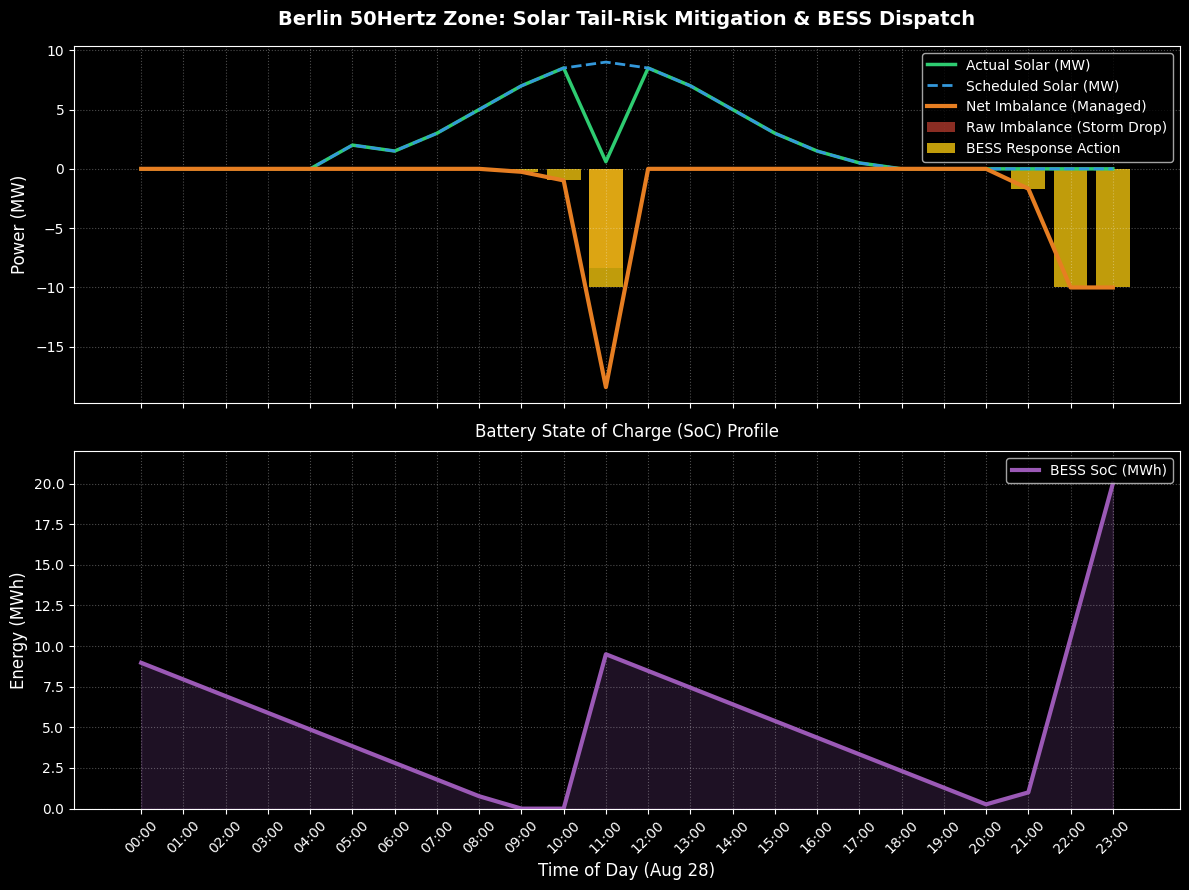

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pulp

# --- 1. DATA & SIMULATION PIPELINE ---
hours = pd.date_range(start="2026-08-28 00:00", periods=24, freq="H")
base_cf = np.array(
    [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.2,
        0.15,
        0.30,
        0.50,
        0.70,
        0.85,
        0.90,
        0.85,
        0.70,
        0.50,
        0.30,
        0.15,
        0.05,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ]
)
actual_cf = base_cf.copy()
actual_cf[11] = 0.06  # Storm shock at hour 11

df = pd.DataFrame(
    {
        "Timestamp": hours,
        "Scheduled_CF": base_cf,
        "Actual_CF": actual_cf,
    }
)
cap_mw = 10.0
df["Scheduled_MW"] = df["Scheduled_CF"] * cap_mw
df["Actual_MW"] = df["Actual_CF"] * cap_mw
df["Imbalance_MW"] = df["Actual_MW"] - df["Scheduled_MW"]
df["Nowcast_Alert"] = False
df.loc[11, "Nowcast_Alert"] = True

id_vwap = 162.0
rebap_spike = 3730.0

# --- 2. OPTIMIZATION MODEL (PuLP) ---
prob = pulp.LpProblem("BESS_TailRisk_Optimization", pulp.LpMinimize)
T = range(24)
max_p = 10.0
max_e = 20.0
initial_soc = 10.0
eta = 0.95

p_charge = pulp.LpVariable.dicts("P_Charge", T, lowBound=0, upBound=max_p)
p_discharge = pulp.LpVariable.dicts("P_Discharge", T, lowBound=0, upBound=max_p)
p_bess = pulp.LpVariable.dicts("P_BESS", T, lowBound=-max_p, upBound=max_p)
soc = pulp.LpVariable.dicts("SoC", T, lowBound=0, upBound=max_e)

for t in T:
  prob += p_bess[t] == p_discharge[t] - p_charge[t]

total_cost = 0
for t in T:
  net_imb = df.loc[t, "Imbalance_MW"] + p_bess[t]
  cost_coeff = (
      id_vwap if df.loc[t, "Nowcast_Alert"] else (rebap_spike if t == 11 else 50.0)
  )
  total_cost += cost_coeff * net_imb

prob += total_cost
prob += soc[0] == initial_soc + (eta * p_charge[0]) - (p_discharge[0] / eta)
for t in range(1, 24):
  prob += soc[t] == soc[t - 1] + (eta * p_charge[t]) - (p_discharge[t] / eta)

prob.solve(pulp.PULP_CBC_CMD(msg=0))

df["BESS_Action_MW"] = [p_bess[t].varValue for t in T]
df["Net_Imbalance_MW"] = df["Imbalance_MW"] + df["BESS_Action_MW"]
df["BESS_SoC_MWh"] = [soc[t].varValue for t in T]

# --- 3. DARK THEME VISUALIZATION ---
plt.style.use("dark_background")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

hours_str = [ts.strftime("%H:00") for ts in df["Timestamp"]]

# Plot 1: Power & Imbalance Mitigation
ax1.plot(
    hours_str,
    df["Actual_MW"],
    label="Actual Solar (MW)",
    color="#2ecc71",
    linewidth=2.5,
)
ax1.plot(
    hours_str,
    df["Scheduled_MW"],
    label="Scheduled Solar (MW)",
    color="#3498db",
    linestyle="--",
    linewidth=2,
)
ax1.bar(
    hours_str,
    df["Imbalance_MW"],
    label="Raw Imbalance (Storm Drop)",
    color="#e74c3c",
    alpha=0.6,
)
ax1.bar(
    hours_str,
    df["BESS_Action_MW"],
    label="BESS Response Action",
    color="#f1c40f",
    alpha=0.8,
)
ax1.plot(
    hours_str,
    df["Net_Imbalance_MW"],
    label="Net Imbalance (Managed)",
    color="#e67e22",
    linewidth=3,
)

ax1.set_title(
    "Berlin 50Hertz Zone: Solar Tail-Risk Mitigation & BESS Dispatch",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax1.set_ylabel("Power (MW)", fontsize=12)
ax1.grid(True, linestyle=":", alpha=0.3)
ax1.legend(loc="upper right", framealpha=0.8)

# Plot 2: State of Charge (SoC)
ax2.plot(
    hours_str,
    df["BESS_SoC_MWh"],
    label="BESS SoC (MWh)",
    color="#9b59b6",
    linewidth=3,
)
ax2.fill_between(
    hours_str, df["BESS_SoC_MWh"], color="#9b59b6", alpha=0.2
)
ax2.set_title("Battery State of Charge (SoC) Profile", fontsize=12, pad=10)
ax2.set_xlabel("Time of Day (Aug 28)", fontsize=12)
ax2.set_ylabel("Energy (MWh)", fontsize=12)
ax2.set_ylim(0, 22)
ax2.grid(True, linestyle=":", alpha=0.3)
ax2.legend(loc="upper right", framealpha=0.8)

plt.xticks(rotation=45)
plt.tight_layout()

# Save high-res output image
plt.savefig("bess_tail_risk_optimizer.png", dpi=300)
plt.show()

In [12]:
pip install numpy pandas pulp matplotlib pillow

/tmp/ipykernel_3960/1395901469.py:8: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



GIF animation successfully saved as bess_optimization_animated.gif


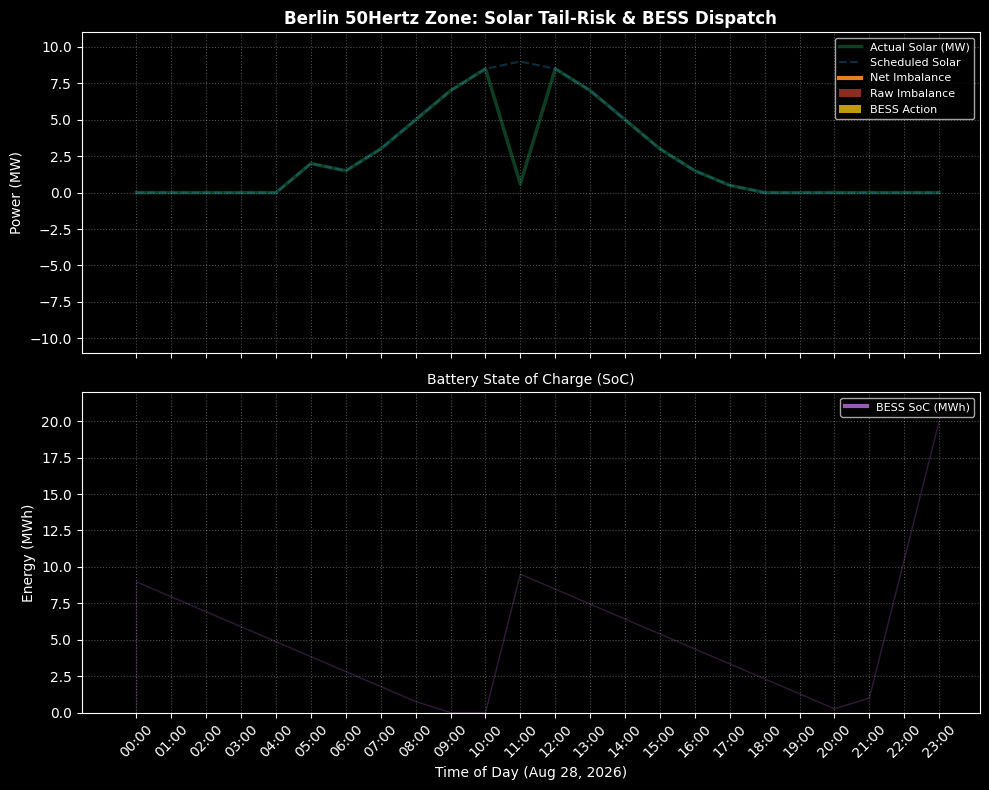

In [13]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pulp

# --- 1. Simulation Data & Model ---
hours = pd.date_range(start="2026-08-28 00:00", periods=24, freq="H")
base_cf = np.array(
    [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.2,
        0.15,
        0.30,
        0.50,
        0.70,
        0.85,
        0.90,
        0.85,
        0.70,
        0.50,
        0.30,
        0.15,
        0.05,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ]
)
actual_cf = base_cf.copy()
actual_cf[11] = 0.06  # Storm shock at hour 11

df = pd.DataFrame(
    {
        "Timestamp": hours,
        "Scheduled_CF": base_cf,
        "Actual_CF": actual_cf,
    }
)
cap_mw = 10.0
df["Scheduled_MW"] = df["Scheduled_CF"] * cap_mw
df["Actual_MW"] = df["Actual_CF"] * cap_mw
df["Imbalance_MW"] = df["Actual_MW"] - df["Scheduled_MW"]
df["Nowcast_Alert"] = False
df.loc[11, "Nowcast_Alert"] = True

# Optimization (PuLP)
prob = pulp.LpProblem("BESS_TailRisk_Optimization", pulp.LpMinimize)
T = range(24)
max_p = 10.0
max_e = 20.0
initial_soc = 10.0
eta = 0.95

p_charge = pulp.LpVariable.dicts("P_Charge", T, lowBound=0, upBound=max_p)
p_discharge = pulp.LpVariable.dicts("P_Discharge", T, lowBound=0, upBound=max_p)
p_bess = pulp.LpVariable.dicts("P_BESS", T, lowBound=-max_p, upBound=max_p)
soc = pulp.LpVariable.dicts("SoC", T, lowBound=0, upBound=max_e)

for t in T:
  prob += p_bess[t] == p_discharge[t] - p_charge[t]

total_cost = 0
for t in T:
  net_imb = df.loc[t, "Imbalance_MW"] + p_bess[t]
  cost_coeff = (
      162.0 if df.loc[t, "Nowcast_Alert"] else (3730.0 if t == 11 else 50.0)
  )
  total_cost += cost_coeff * net_imb

prob += total_cost
prob += soc[0] == initial_soc + (eta * p_charge[0]) - (p_discharge[0] / eta)
for t in range(1, 24):
  prob += soc[t] == soc[t - 1] + (eta * p_charge[t]) - (p_discharge[t] / eta)

prob.solve(pulp.PULP_CBC_CMD(msg=0))

df["BESS_Action_MW"] = [p_bess[t].varValue for t in T]
df["Net_Imbalance_MW"] = df["Imbalance_MW"] + df["BESS_Action_MW"]
df["BESS_SoC_MWh"] = [soc[t].varValue for t in T]

# --- 2. Dark Theme GIF Animation Setup ---
plt.style.use("dark_background")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
hours_str = [ts.strftime("%H:00") for ts in df["Timestamp"]]


def update(num):
  ax1.clear()
  ax2.clear()

  sub_df = df.iloc[: num + 1]
  sub_hours = hours_str[: num + 1]

  # Plot 1: Power & Imbalance
  ax1.plot(
      hours_str,
      df["Actual_MW"],
      label="Actual Solar (MW)",
      color="#2ecc71",
      linewidth=2.5,
      alpha=0.3,
  )
  ax1.plot(
      hours_str,
      df["Scheduled_MW"],
      label="Scheduled Solar",
      color="#3498db",
      linestyle="--",
      linewidth=1.5,
      alpha=0.3,
  )

  if len(sub_df) > 0:
    ax1.plot(sub_hours, sub_df["Actual_MW"], color="#2ecc71", linewidth=2.5)
    ax1.plot(
        sub_hours, sub_df["Scheduled_MW"], color="#3498db", linestyle="--", linewidth=2
    )
    ax1.bar(
        sub_hours,
        sub_df["Imbalance_MW"],
        color="#e74c3c",
        alpha=0.6,
        label="Raw Imbalance",
    )
    ax1.bar(
        sub_hours,
        sub_df["BESS_Action_MW"],
        color="#f1c40f",
        alpha=0.8,
        label="BESS Action",
    )
    ax1.plot(
        sub_hours,
        sub_df["Net_Imbalance_MW"],
        color="#e67e22",
        linewidth=3,
        label="Net Imbalance",
    )

  ax1.set_title(
      "Berlin 50Hertz Zone: Solar Tail-Risk & BESS Dispatch",
      fontsize=12,
      fontweight="bold",
  )
  ax1.set_ylabel("Power (MW)")
  ax1.set_ylim(-11, 11)
  ax1.grid(True, linestyle=":", alpha=0.3)
  ax1.legend(loc="upper right", fontsize=8)

  # Plot 2: SoC Profile
  ax2.plot(
      hours_str, df["BESS_SoC_MWh"], color="#9b59b6", linewidth=1, alpha=0.3
  )
  if len(sub_df) > 0:
    ax2.plot(
        sub_hours,
        sub_df["BESS_SoC_MWh"],
        color="#9b59b6",
        linewidth=3,
        label="BESS SoC (MWh)",
    )
    ax2.fill_between(sub_hours, sub_df["BESS_SoC_MWh"], color="#9b59b6", alpha=0.2)

  ax2.set_title("Battery State of Charge (SoC)", fontsize=10)
  ax2.set_xlabel("Time of Day (Aug 28, 2026)")
  ax2.set_ylabel("Energy (MWh)")
  ax2.set_ylim(0, 22)
  ax2.grid(True, linestyle=":", alpha=0.3)
  ax2.legend(loc="upper right", fontsize=8)
  plt.xticks(rotation=45)
  plt.tight_layout()


anim = animation.FuncAnimation(
    fig, update, frames=len(df), interval=400, repeat=True
)
anim.save("bess_optimization_animated.gif", writer="pillow", dpi=100, fps=3)
print("GIF animation successfully saved as bess_optimization_animated.gif")